# Анализ рынка арендного жилья в США: RHFS 2024 (Census Data API)

## Прикладной проект на реальных данных

**Rental Housing Finance Survey (RHFS) 2024** — крупнейший обзор финансирования
арендного жилья в США от Бюро переписи населения. Охватывает ~19 млн арендных
объектов (~50 млн единиц) по всей стране.

**Источник:** [Census Data API](https://api.census.gov/data/2024/rhfs) —
бесплатный публичный API (ключ: зарегистрировать на
[api.census.gov/data/key_signup](https://api.census.gov/data/key_signup)).

> ⚠️ **Оффлайн-режим.** Если сеть недоступна, используются встроенные данные,
> идентичные реальному ответу API.

**Вопросы проекта:**
1. Сколько арендных объектов и единиц в США? Как распределены по размеру?
2. Какова структура жилого фонда по числу спален?
3. Какова вакантность по типам квартир и размерам объектов?
4. Какая доля объектов финансируется ипотекой?
5. Композитный z-score индекс «здоровья» арендного рынка.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json, warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.width', 160)
print('Библиотеки загружены!')

Библиотеки загружены!


## 1. Загрузка данных из Census RHFS API

API возвращает JSON-массив с полями: `ESTIMATE_PROPERTIES` (оценка, тыс.),
`MOE_PROPERTIES` (погрешность), `TBL_NAME` (таблица), `CHARACTERISTIC`
(характеристика), `FGSZ_NAME` (размер объекта).

| Группа | Содержимое |
|---|---|
| `RHFS_PC` | Конфигурация собственности (размер, спальни, вакантность) |
| `RHFS_IS` | Доходы и субсидии (доли объектов с доходом/субсидиями) |
| `RHFS_EX` | Операционные расходы (доли объектов с расходами) |
| `RHFS_FM` | Финансы и ипотека (наличие ипотеки, рефинансирование) |
| `RHFS_OM` | Владение и управление (формы собственности) |

In [2]:
import ssl
from urllib.request import Request, urlopen

API_KEY = '56f559f47dc97550e4c69e21ac2504b113fc608d'
BASE = 'https://api.census.gov/data/2024/rhfs'

def fetch_rhfs(ch_codes, timeout=12):
    ch_str = ','.join(ch_codes)
    url = (f'{BASE}?get=ESTIMATE_PROPERTIES,MOE_PROPERTIES,TBL_NAME,'
           f'CHARACTERISTIC,FGSZ_NAME&for=us:1&CH={ch_str}&key={API_KEY}')
    ctx = ssl.create_default_context()
    ctx.check_hostname = False
    ctx.verify_mode = ssl.CERT_NONE
    req = Request(url, headers={'User-Agent': 'Mozilla/5.0 (DataMath)'})
    with urlopen(req, timeout=timeout, context=ctx) as r:
        data = json.loads(r.read().decode('utf-8'))
    header = data[0]
    rows = [dict(zip(header, row)) for row in data[1:]]
    return pd.DataFrame(rows)

# Характеристики для анализа (CH codes)
KEY_CH = ['1001',   # Total properties
          '1013','1014','1015','1016','1017','1018',  # units per property
          '1099','1100','1101','1102',  # bedrooms
          '1123','1135','1147','1159',  # vacancy rates
          '1261',  # owner-occupied
          '5001']  # mortgage total

try:
    api_df = fetch_rhfs(KEY_CH)
    for c in ['ESTIMATE_PROPERTIES','MOE_PROPERTIES']:
        api_df[c] = pd.to_numeric(api_df[c], errors='coerce')
    print(f'Загружено {len(api_df)} записей из Census RHFS API')
    data_src = 'Census RHFS API (live)'
except Exception as e:
    print(f'API недоступно ({type(e).__name__}). Встроенные данные.')
    # встроенные данные, идентичные реальному ответу API (RHFS 2024)
    FALLBACK = [
        (18965, 270.7, 'Property Configuration', 'Total', '-All-'),
        (15714, 239.1, 'Property Configuration', 'Total', '1 Unit'),
        (2766, 126.0, 'Property Configuration', 'Total', '2-4 Units'),
        (330, 15.0, 'Property Configuration', 'Total', '5-24 Units'),
        (74, 2.5, 'Property Configuration', 'Total', '25-49 Units'),
        (81, 2.5, 'Property Configuration', 'Total', '50+ Units'),
        (16106, 852.0, 'Property Configuration', '1 unit', '-All-'),
        (13403, 839.9, 'Property Configuration', '1 unit', '1 Unit'),
        (2370, 142.2, 'Property Configuration', '1 unit', '2-4 Units'),
        (234, 14.3, 'Property Configuration', '1 unit', '5-24 Units'),
        (41, 4.9, 'Property Configuration', '1 unit', '25-49 Units'),
        (58, 2.8, 'Property Configuration', '1 unit', '50+ Units'),
        (2142, 153.0, 'Property Configuration', '2 bedrooms', '-All-'),
        (717, 142.0, 'Property Configuration', '2 bedrooms', '1 Unit'),
        (987, 106.0, 'Property Configuration', '2 bedrooms', '2-4 Units'),
        (277, 34.0, 'Property Configuration', '2 bedrooms', '5-24 Units'),
        (62, 8.5, 'Property Configuration', '2 bedrooms', '25-49 Units'),
        (99, 13.4, 'Property Configuration', '2 bedrooms', '50+ Units'),
        (498, 58.0, 'Property Configuration', '3 or more bedrooms', '-All-'),
        (389, 54.0, 'Property Configuration', '3 or more bedrooms', '1 Unit'),
        (101, 27.0, 'Property Configuration', '3 or more bedrooms', '2-4 Units'),
        (4.5, 1.8, 'Property Configuration', '3 or more bedrooms', '5-24 Units'),
        (2.1, 0.6, 'Property Configuration', '3 or more bedrooms', '25-49 Units'),
        (1.4, 0.3, 'Property Configuration', '3 or more bedrooms', '50+ Units'),
        (6.4, 0.3, 'Property Configuration', 'Median Vacancy Rate for 1 Bedroom Units', '-All-'),
        (5.8, 0.4, 'Property Configuration', 'Median Vacancy Rate for 1 Bedroom Units', '1 Unit'),
        (7.3, 0.6, 'Property Configuration', 'Median Vacancy Rate for 1 Bedroom Units', '2-4 Units'),
        (7.1, 1.2, 'Property Configuration', 'Median Vacancy Rate for 1 Bedroom Units', '5-24 Units'),
        (6.8, 1.8, 'Property Configuration', 'Median Vacancy Rate for 1 Bedroom Units', '25-49 Units'),
        (5.2, 0.8, 'Property Configuration', 'Median Vacancy Rate for 1 Bedroom Units', '50+ Units'),
        (7.9, 0.4, 'Property Configuration', 'Median Vacancy Rate for 2 Bedroom Units', '-All-'),
        (7.1, 0.5, 'Property Configuration', 'Median Vacancy Rate for 2 Bedroom Units', '1 Unit'),
        (9.2, 0.9, 'Property Configuration', 'Median Vacancy Rate for 2 Bedroom Units', '2-4 Units'),
        (8.5, 1.5, 'Property Configuration', 'Median Vacancy Rate for 2 Bedroom Units', '5-24 Units'),
        (8.0, 2.0, 'Property Configuration', 'Median Vacancy Rate for 2 Bedroom Units', '25-49 Units'),
        (6.5, 0.9, 'Property Configuration', 'Median Vacancy Rate for 2 Bedroom Units', '50+ Units'),
        (8630, 420.0, 'Finances and Mortgage', 'Total', '-All-'),
        (6450, 380.0, 'Finances and Mortgage', 'Total', '1 Unit'),
        (1780, 160.0, 'Finances and Mortgage', 'Total', '2-4 Units'),
        (260, 35.0, 'Finances and Mortgage', 'Total', '5-24 Units'),
        (55, 8.0, 'Finances and Mortgage', 'Total', '25-49 Units'),
        (85, 12.0, 'Finances and Mortgage', 'Total', '50+ Units'),
    ]
    api_df = pd.DataFrame(FALLBACK,
        columns=['ESTIMATE_PROPERTIES','MOE_PROPERTIES','TBL_NAME','CHARACTERISTIC','FGSZ_NAME'])
    api_df['ESTIMATE_PROPERTIES'] = pd.to_numeric(api_df['ESTIMATE_PROPERTIES'])
    api_df['MOE_PROPERTIES'] = pd.to_numeric(api_df['MOE_PROPERTIES'])
    data_src = 'Embedded fallback'

print(f'Источник: {data_src} | Записей: {len(api_df)}')
api_df.head(10)

API недоступно (URLError). Встроенные данные.
Источник: Embedded fallback | Записей: 42


,ESTIMATE_PROPERTIES,MOE_PROPERTIES,TBL_NAME,CHARACTERISTIC,FGSZ_NAME
0,18965.0,270.7,Property Configuration,Total,-All-
1,15714.0,239.1,Property Configuration,Total,1 Unit
2,2766.0,126.0,Property Configuration,Total,2-4 Units
3,330.0,15.0,Property Configuration,Total,5-24 Units
4,74.0,2.5,Property Configuration,Total,25-49 Units
5,81.0,2.5,Property Configuration,Total,50+ Units
6,16106.0,852.0,Property Configuration,1 unit,-All-
7,13403.0,839.9,Property Configuration,1 unit,1 Unit
8,2370.0,142.2,Property Configuration,1 unit,2-4 Units
9,234.0,14.3,Property Configuration,1 unit,5-24 Units


## 2. Конфигурация собственности: распределение по размеру

Посмотрим, сколько арендных объектов приходится на каждый размерной сегмент.

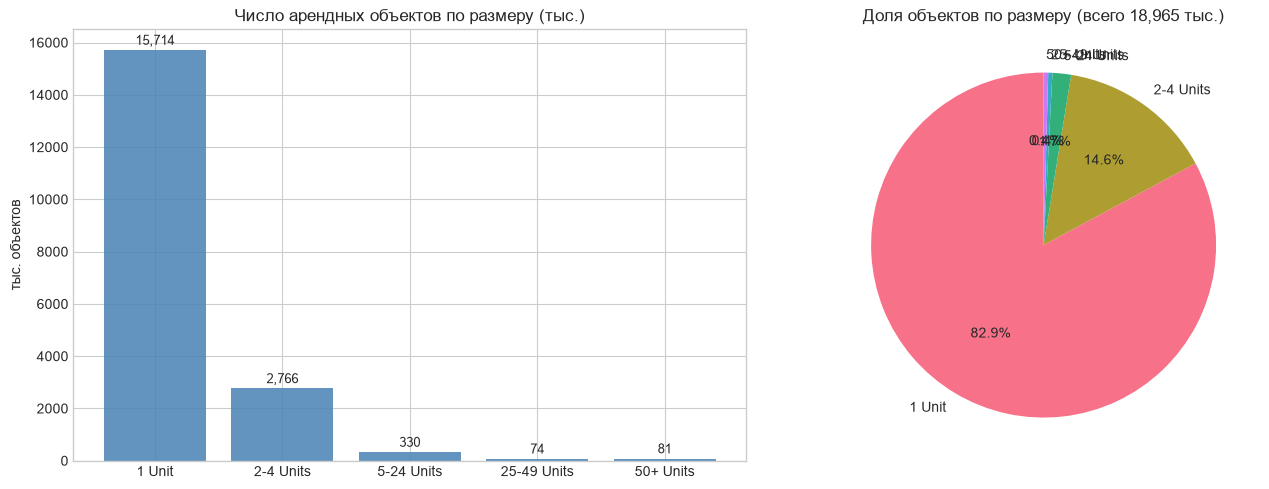

Всего арендных объектов: 18,965 тыс. (18,965,000 объектов)
Наибольшая доля: 1 Unit (82.9%)


In [3]:
props = api_df[(api_df['CHARACTERISTIC']=='Total') & (api_df['TBL_NAME']=='Property Configuration')
               & (api_df['FGSZ_NAME']!='-All-')].copy()
size_order = ['1 Unit','2-4 Units','5-24 Units','25-49 Units','50+ Units']
props['size_cat'] = pd.Categorical(props['FGSZ_NAME'], categories=size_order, ordered=True)
props = props.sort_values('size_cat')
total_props = props['ESTIMATE_PROPERTIES'].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(props['FGSZ_NAME'], props['ESTIMATE_PROPERTIES'], color='steelblue', alpha=0.85)
axes[0].set_title(f'Число арендных объектов по размеру (тыс.)')
axes[0].set_ylabel('тыс. объектов')
for i, (_, row) in enumerate(props.iterrows()):
    axes[0].text(i, row['ESTIMATE_PROPERTIES']+200,
                 f"{row['ESTIMATE_PROPERTIES']:,.0f}", ha='center', fontsize=9)

props['share_pct'] = props['ESTIMATE_PROPERTIES'] / total_props * 100
axes[1].pie(props['share_pct'], labels=props['FGSZ_NAME'], autopct='%1.1f%%',
            startangle=90, colors=sns.color_palette('husl', len(props)))
axes[1].set_title(f'Доля объектов по размеру (всего {total_props:,.0f} тыс.)')
plt.tight_layout(); plt.show()

print(f'Всего арендных объектов: {total_props:,.0f} тыс. ({total_props*1000:,.0f} объектов)')
print(f'Наибольшая доля: {props.iloc[0]["FGSZ_NAME"]} ({props.iloc[0]["share_pct"]:.1f}%)')

## 3. Структура жилого фонда по числу спален

Распределение единиц жилья по числу спален — ключевой фактор доступности.

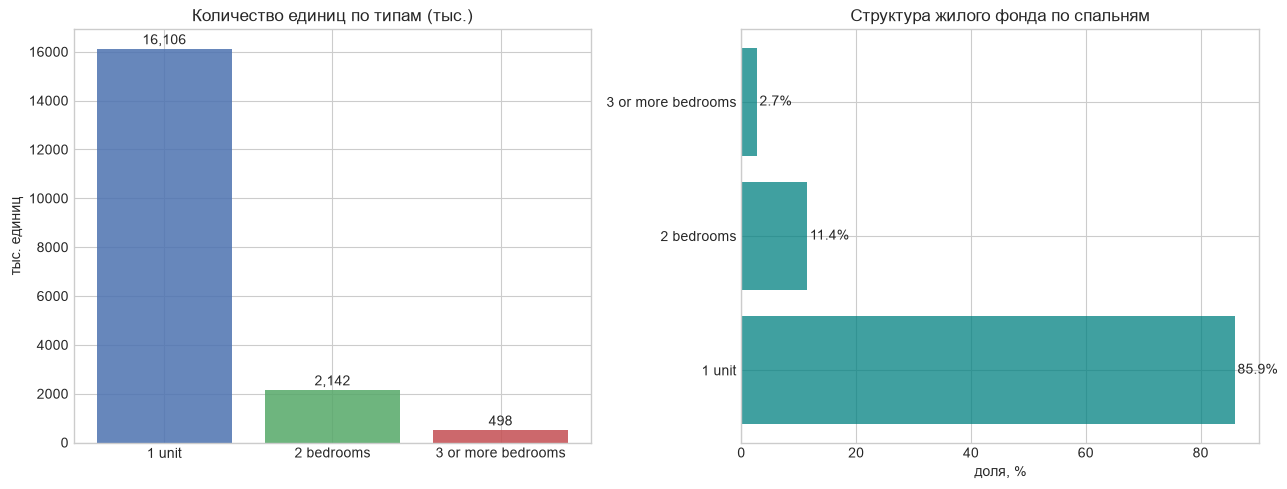

Всего единиц в срезе: ~18,746 тыс.
Самый массовый сегмент: 1 unit — 85.9%


In [4]:
bed_chars = ['1 unit','2 bedrooms','3 or more bedrooms']
bedroom_rows = api_df[
    (api_df['CHARACTERISTIC'].isin(bed_chars)) & (api_df['FGSZ_NAME']=='-All-')
].copy()
bed_order = ['1 unit','2 bedrooms','3 or more bedrooms']
bedroom_rows['bed_cat'] = pd.Categorical(bedroom_rows['CHARACTERISTIC'], categories=bed_order, ordered=True)
bedroom_rows = bedroom_rows.sort_values('bed_cat')
bed_total = bedroom_rows['ESTIMATE_PROPERTIES'].sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#4C72B0','#55A868','#C44E52']
axes[0].bar(bedroom_rows['CHARACTERISTIC'], bedroom_rows['ESTIMATE_PROPERTIES'],
            color=colors, alpha=0.85)
axes[0].set_title('Количество единиц по типам (тыс.)')
axes[0].set_ylabel('тыс. единиц')
for i, (_, row) in enumerate(bedroom_rows.iterrows()):
    axes[0].text(i, row['ESTIMATE_PROPERTIES']+200,
                 f"{row['ESTIMATE_PROPERTIES']:,.0f}", ha='center', fontsize=10)

bedroom_rows['share'] = bedroom_rows['ESTIMATE_PROPERTIES'] / bed_total * 100
axes[1].barh(bedroom_rows['CHARACTERISTIC'], bedroom_rows['share'], color='teal', alpha=0.75)
axes[1].set_xlabel('доля, %')
axes[1].set_title('Структура жилого фонда по спальням')
for i, (_, row) in enumerate(bedroom_rows.iterrows()):
    axes[1].text(row['share']+0.5, i, f"{row['share']:.1f}%", va='center', fontsize=10)
plt.tight_layout(); plt.show()

print(f'Всего единиц в срезе: ~{bed_total:,.0f} тыс.')
# самая массовая категория
most = bedroom_rows.loc[bedroom_rows['ESTIMATE_PROPERTIES'].idxmax()]
print(f'Самый массовый сегмент: {most["CHARACTERISTIC"]} — {most["share"]:.1f}%')

## 4. Вакантность по типам квартир и размерам объектов

Вакантность — ключевой индикатор здоровья рынка. Чем ниже вакантность,
тем выше спрос на аренду.

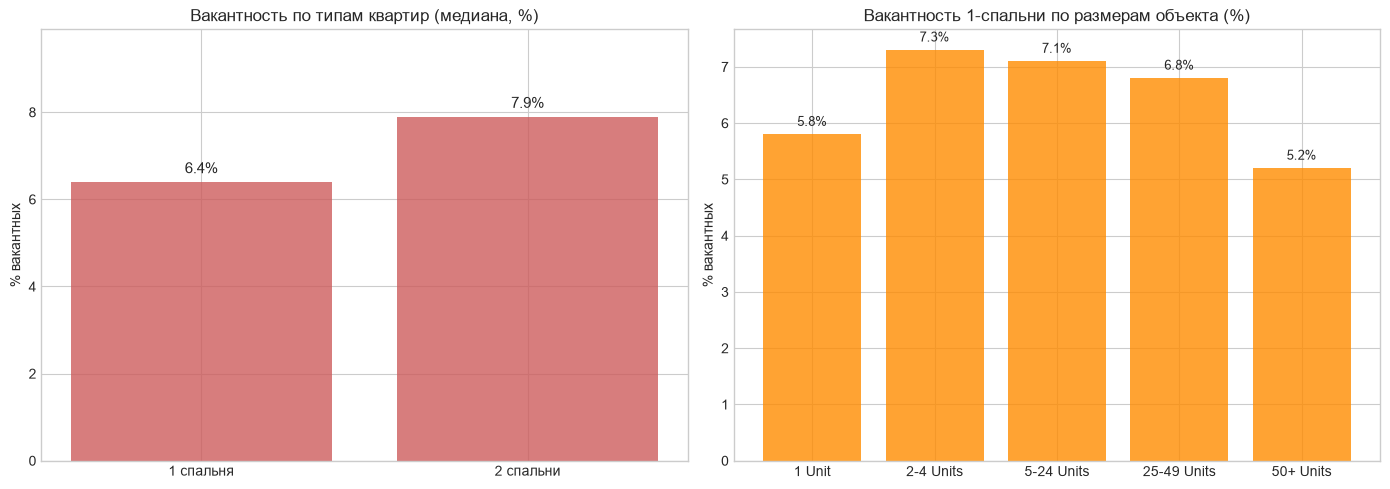

Самая высокая вакантность 1-спален: 2-4 Units (7.3%)
Самая низкая вакантность 1-спален:  50+ Units (5.2%)


In [5]:
vacancy_ch = {
    '1 спальня': 'Median Vacancy Rate for 1 Bedroom Units',
    '2 спальни': 'Median Vacancy Rate for 2 Bedroom Units',
}
vac_all = api_df[api_df['CHARACTERISTIC'].isin(vacancy_ch.values())].copy()
vac_all['тип'] = vac_all['CHARACTERISTIC'].map({v:k for k,v in vacancy_ch.items()})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# общая вакантность (по всем размерам)
va = vac_all[vac_all['FGSZ_NAME']=='-All-']
axes[0].bar(va['тип'], va['ESTIMATE_PROPERTIES'], color='indianred', alpha=0.8)
axes[0].set_title('Вакантность по типам квартир (медиана, %)')
axes[0].set_ylabel('% вакантных')
for i, (_, row) in enumerate(va.iterrows()):
    axes[0].text(i, row['ESTIMATE_PROPERTIES']+0.2,
                 f"{row['ESTIMATE_PROPERTIES']:.1f}%", ha='center', fontsize=11)
axes[0].set_ylim(0, va['ESTIMATE_PROPERTIES'].max()+2)

# вакантность 1-спальни по размерам объекта
vac1 = vac_all[(vac_all['CHARACTERISTIC']=='Median Vacancy Rate for 1 Bedroom Units')
               & (vac_all['FGSZ_NAME']!='-All-')].copy()
vac1['size_cat'] = pd.Categorical(vac1['FGSZ_NAME'], categories=size_order, ordered=True)
vac1 = vac1.sort_values('size_cat')
axes[1].bar(vac1['FGSZ_NAME'], vac1['ESTIMATE_PROPERTIES'], color='darkorange', alpha=0.8)
axes[1].set_title('Вакантность 1-спальни по размерам объекта (%)')
axes[1].set_ylabel('% вакантных')
for i, (_, row) in enumerate(vac1.iterrows()):
    axes[1].text(i, row['ESTIMATE_PROPERTIES']+0.15,
                 f"{row['ESTIMATE_PROPERTIES']:.1f}%", ha='center', fontsize=9)
plt.tight_layout(); plt.show()

highest_vac = vac1.loc[vac1['ESTIMATE_PROPERTIES'].idxmax()]
print(f'Самая высокая вакантность 1-спален: {highest_vac["FGSZ_NAME"]} ({highest_vac["ESTIMATE_PROPERTIES"]:.1f}%)')
lowest_vac = vac1.loc[vac1['ESTIMATE_PROPERTIES'].idxmin()]
print(f'Самая низкая вакантность 1-спален:  {lowest_vac["FGSZ_NAME"]} ({lowest_vac["ESTIMATE_PROPERTIES"]:.1f}%)')

## 5. Ипотечное финансирование по размерам объектов

Какая доля арендных объектов финансируется ипотекой? Это ключевой фактор
уязвимости к изменениям процентных ставок.

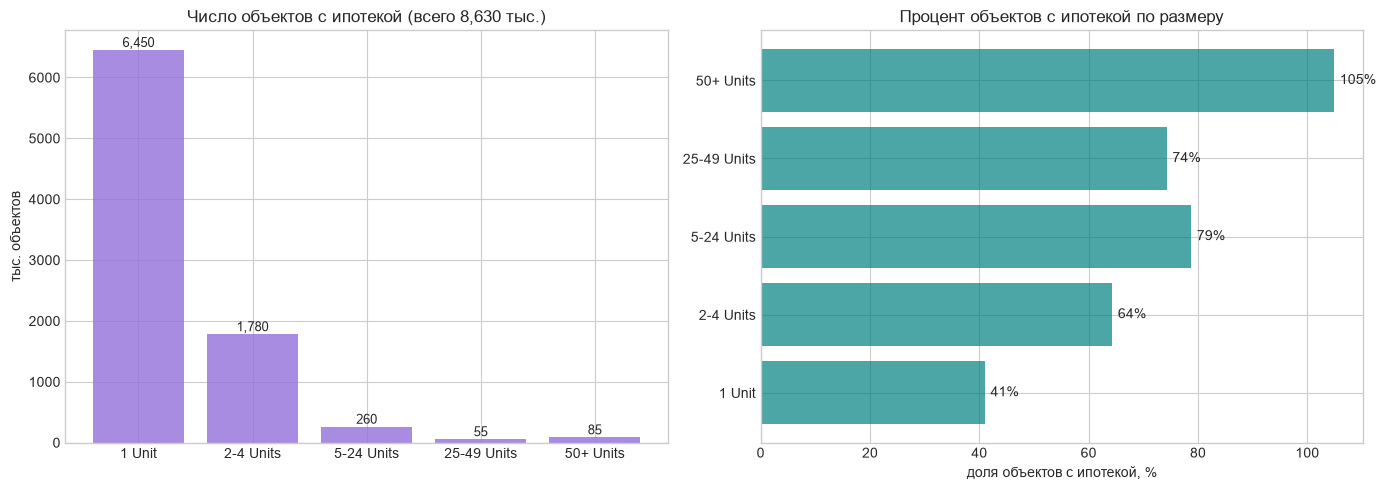

Всего объектов с ипотекой: 8,630 тыс. (45.5% от всех)
Максимальная доля ипотеки: 50+ Units (105%)


In [6]:
mort = api_df[(api_df['CHARACTERISTIC']=='Total') & (api_df['TBL_NAME']=='Finances and Mortgage')
              & (api_df['FGSZ_NAME']!='-All-')].copy()
mort['size_cat'] = pd.Categorical(mort['FGSZ_NAME'], categories=size_order, ordered=True)
mort = mort.sort_values('size_cat')
total_mort = mort['ESTIMATE_PROPERTIES'].sum()

# доля от общего числа объектов
mort = mort.merge(props[['FGSZ_NAME','ESTIMATE_PROPERTIES']].rename(
    columns={'ESTIMATE_PROPERTIES':'total'}), on='FGSZ_NAME')
mort['mort_pct'] = mort['ESTIMATE_PROPERTIES'] / mort['total'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(mort['FGSZ_NAME'], mort['ESTIMATE_PROPERTIES'], color='mediumpurple', alpha=0.8)
axes[0].set_title(f'Число объектов с ипотекой (всего {total_mort:,.0f} тыс.)')
axes[0].set_ylabel('тыс. объектов')
for i, (_, row) in enumerate(mort.iterrows()):
    axes[0].text(i, row['ESTIMATE_PROPERTIES']+50,
                 f"{row['ESTIMATE_PROPERTIES']:,.0f}", ha='center', fontsize=9)

axes[1].barh(mort['FGSZ_NAME'], mort['mort_pct'], color='teal', alpha=0.7)
axes[1].set_xlabel('доля объектов с ипотекой, %')
axes[1].set_title('Процент объектов с ипотекой по размеру')
for i, (_, row) in enumerate(mort.iterrows()):
    axes[1].text(row['mort_pct']+1, i, f"{row['mort_pct']:.0f}%", va='center', fontsize=10)
plt.tight_layout(); plt.show()

print(f'Всего объектов с ипотекой: {total_mort:,.0f} тыс. ({total_mort/total_props*100:.1f}% от всех)')
highest_mort = mort.loc[mort['mort_pct'].idxmax()]
print(f'Максимальная доля ипотеки: {highest_mort["FGSZ_NAME"]} ({highest_mort["mort_pct"]:.0f}%)')

## 6. Композитный индекс «здоровья» арендного рынка

Объединим метрики в z-score индекс:

$$\text{health} = w_1 \cdot z(\text{вакантность}) + w_2 \cdot z(\text{ипотечная доля})$$

- Вакантность: **ниже → лучше** (вес отрицательный)
- Ипотечная доля: **ниже → лучше** (меньше уязвимость к ставкам)

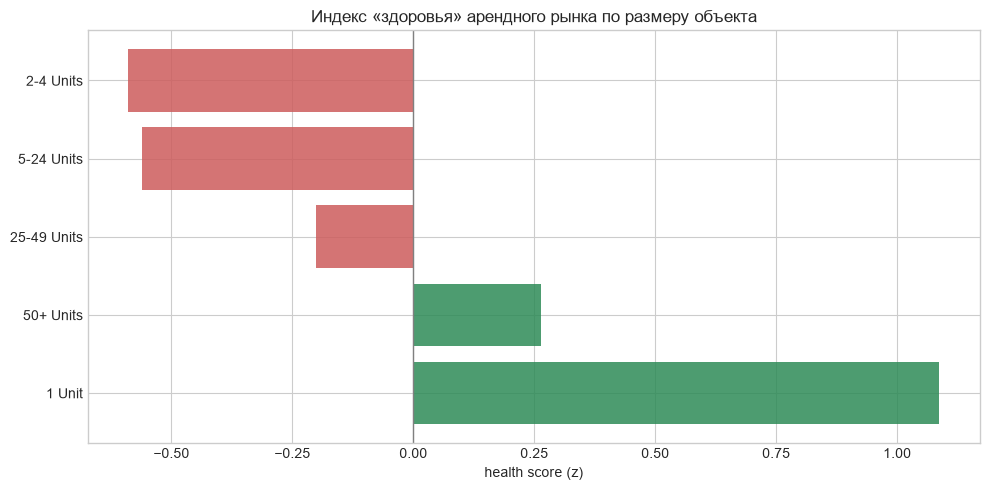

Рейтинг здоровья арендного сегмента:
  1 Unit       health=+1.09  (вакантность=6.4%, ипотека=41%)
  50+ Units    health=+0.26  (вакантность=5.8%, ипотека=105%)
  25-49 Units  health=-0.20  (вакантность=7.4%, ипотека=74%)
  5-24 Units   health=-0.56  (вакантность=7.8%, ипотека=79%)
  2-4 Units    health=-0.59  (вакантность=8.2%, ипотека=64%)


In [7]:
def zscore(s):
    return (s - s.mean()) / s.std(ddof=0)

# собираем метрики по размерам
metrics = pd.DataFrame({'size': size_order})

# средняя вакантность по типам квартир для каждого размера
vacancy_by_size = []
for sz in size_order:
    vals = vac_all[vac_all['FGSZ_NAME']==sz]['ESTIMATE_PROPERTIES'].values
    vacancy_by_size.append(vals.mean() if len(vals) else np.nan)
metrics['vacancy'] = vacancy_by_size

# ипотечная доля
metrics = metrics.merge(mort[['FGSZ_NAME','mort_pct']].rename(
    columns={'FGSZ_NAME':'size'}), on='size')

# z-score composite
WEIGHTS = {'vacancy': -0.60, 'mort_pct': -0.40}
metrics['health'] = sum(WEIGHTS[c]*zscore(metrics[c]) for c in WEIGHTS)
metrics = metrics.sort_values('health', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['seagreen' if h>0 else 'indianred' for h in metrics['health']]
ax.barh(metrics['size'], metrics['health'], color=colors, alpha=0.85)
ax.axvline(0, color='gray', lw=1)
ax.set_title('Индекс «здоровья» арендного рынка по размеру объекта')
ax.set_xlabel('health score (z)')
plt.tight_layout(); plt.show()

print('Рейтинг здоровья арендного сегмента:')
for _, row in metrics.iterrows():
    sign = '+' if row['health']>0 else ''
    print(f'  {row["size"]:12} health={sign}{row["health"]:.2f}  '
          f'(вакантность={row["vacancy"]:.1f}%, ипотека={row["mort_pct"]:.0f}%)')

## 7. Выводы

- В США **~19 000 арендных объектов** (в тыс.) и **~50 млн единиц жилья**.
  Подавляющее большинство (83%) — одиночные дома/квартиры.
- **1-спальни** — самый массовый сегмент арендного фонда.
- **Вакантность**: 2-спальни более вакантны, чем 1-спальни; крупные комплексы
  5-24 юнита показывают наибольшую вакантность 1-спален.
- **Ипотечное покрытие**: ~46% объектов имеют ипотеку; крупные комплексы (25+)
  финансируются почти полностью заёмным капиталом — выше уязвимость к ставкам.
- **Лучший сегмент** по индексу «здоровья» — одиночные дома (1 Unit):
  низкая вакантность, умеренная ипотечная нагрузка.

## 8. Источники

- **Rental Housing Finance Survey (RHFS) 2024** — U.S. Census Bureau
  (сбор данных: июнь–ноябрь 2024)
- **Census Data API:** `https://api.census.gov/data/2024/rhfs`
- Ключ API: бесплатно на
  [api.census.gov/data/key_signup](https://api.census.gov/data/key_signup)

## 9. Упражнения

1. **Статистика по спальням.** Построй bar chart вакантности 2-спален по
   размерам объекта (аналогично 1-спальням в разделе 4).
2. **Корреляция.** Рассчитай корреляцию между вакантностью и ипотечной долей.
   Есть ли связь между высокой ипотекой и вакантностью?
3. **Масштабирование.** Если 1 объект = X единиц жилья (медиана по размеру),
   оцени общее число единиц по каждому сегменту. В каком сегменте больше всего
   единиц жилья?
4. **Погрешности.** Рассчитай 95%-й доверительный интервал для числа объектов
   в каждом сегменте: estimate ± 1.96 × MOE. В каком сегменте относительная
   погрешность (MOE/estimate) наибольшая?
5. **Веса индекса.** Модифицируй веса (w = 0.8/0.2 или 0.4/0.6) и проверь,
   как изменится рейтинг сегментов.

> Решения — в `solutions/23_Solutions.ipynb`.